# 🟢 CORRECTION DE L'EXAMEN : Analyse Exploratoire de TheLook eCommerce

Ce notebook contient la correction détaillée de l'examen final. 
Prenez le temps de lire les cellules markdown et les commentaires dans le code pour comprendre la démarche.

In [11]:
# Import des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 🛠️ PARTIE 1 : Chargement & Exploration Initiale (Pandas)
*Valide les compétences du Notebook 2 (Pandas Premiers Pas).*

In [12]:
# 1. Chargez le dataset
df = pd.read_csv('../../01_data/capstone/thelook_capstone.csv')
df.head()

,id,order_id,user_id,product_id,sale_price,status,created_at,shipped_at,delivered_at,returned_at,...,cost,gender,age,country,city,traffic_source,first_name,last_name,email,notes
0,1,2006,3641,533,37.47,Complete,2023-05-24 05:04:44,2023-05-25 05:04:44,2023-05-30 05:04:44,NaN,...,$27.45,F,27.0,Australia,Perth,Search,Jennifer,Smith,jennifer.smith131@example.com,NaN
1,2,19606,4289,1234,41.01,Complete,2024-06-14 02:09:32,2024-06-16 02:09:32,2024-06-19 02:09:32,NaN,...,$23.79,M,39.0,Mexico,Guadalajara,Search,Mark,Wilson,mark.wilson338@example.com,NaN
2,3,14234,973,409,15.67,Complete,2023-06-16 03:42:36,2023-06-17 03:42:36,2023-06-25 03:42:36,NaN,...,$8.97,F,45.0,Poland,Warsaw,Search,Amanda,Brown,amanda.brown394@example.com,NaN
3,4,14616,2136,67,75.15,Complete,2024-12-01 13:36:46,2024-12-03 13:36:46,2024-12-08 13:36:46,NaN,...,$37.25,M,36.0,Spain,Seville,Organic,Paul,Martinez,paul.martinez895@example.com,NaN
4,5,7423,4007,1882,18.20,Complete,2024-08-21 13:24:24,2024-08-22 13:24:24,NaN,NaN,...,$14.42,F,NaN,United Kingdom,Manchester,Organic,Margaret,Jackson,margaret.jackson436@example.com,NaN


In [13]:
# 2. Affichez les infos générales (lignes, colonnes, types)
print("Forme du dataset :", df.shape)
display(df.info())

Forme du dataset : (51000, 24)
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              51000 non-null  int64  
 1   order_id        51000 non-null  int64  
 2   user_id         51000 non-null  int64  
 3   product_id      51000 non-null  int64  
 4   sale_price      49538 non-null  float64
 5   status          51000 non-null  str    
 6   created_at      51000 non-null  str    
 7   shipped_at      42976 non-null  str    
 8   delivered_at    33064 non-null  str    
 9   returned_at     3581 non-null   str    
 10  product_name    51000 non-null  str    
 11  category        47272 non-null  str    
 12  brand           51000 non-null  str    
 13  department      51000 non-null  str    
 14  cost            51000 non-null  str    
 15  gender          51000 non-null  str    
 16  age             48450 non-null  float64
 17  country    

None

> ✍️ **Interprétation (Markdown) :**
> - La colonne `created_at` est reconnue comme `object` (texte) alors que ce devrait être une date.
> - La colonne `cost` est aussi en `object` à cause du symbole `$`, ce qui bloque les calculs mathématiques.
> - On observe que des colonnes comme `age`, `sale_price` et `delivered_at` n'ont pas 100% de données non-nulles, il y a donc des valeurs manquantes (NaN).

---
## 🧹 PARTIE 2 : Le Nettoyage de Données (Le cœur du travail)
*Valide les compétences du Notebook 4 (Nettoyage). Pensez à justifier vos choix !*

### 2.1 Les valeurs manquantes (NaN)

In [14]:
# Identifiez le pourcentage de valeurs manquantes par colonne
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

notes           96.096078
returned_at     92.978431
delivered_at    35.168627
shipped_at      15.733333
category         7.309804
age              5.000000
sale_price       2.866667
dtype: float64

> ✍️ **Vos choix d'imputation :**
> - **`age`** et **`sale_price`** : On va remplacer les valeurs manquantes par la **médiane**, car la moyenne est trop sensible aux éventuels âges à 120 ans ou prix démesurés (outliers).
> - **`delivered_at`** : On laisse les NaN ! Si la date de livraison manque, cela signifie fort probablement que la commande est en transit ou annulée. Remplacer par une fausse date fausserait l'analyse des délais de livraison.

In [15]:
# Appliquez vos stratégies de traitement des NaN
df['age'] = df['age'].fillna(df['age'].median())
df['sale_price'] = df['sale_price'].fillna(df['sale_price'].median())

print("NaN restants pour age :", df['age'].isna().sum())
print("NaN restants pour sale_price :", df['sale_price'].isna().sum())

NaN restants pour age : 0
NaN restants pour sale_price : 0


### 2.2 Doublons et types incorrects

In [16]:
# Détectez et supprimez les doublons exacts
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons avant nettoyage : {nb_doublons}")

df = df.drop_duplicates()
print(f"Nombre de doublons après nettoyage : {df.duplicated().sum()}")

Nombre de doublons avant nettoyage : 648
Nombre de doublons après nettoyage : 0


In [17]:
# Corrigez la colonne 'cost' (qui contient actuellement du texte avec le symbole '$') pour la transformer en Float
df['cost'] = df['cost'].str.replace('$', '', regex=False).astype(float)
print("Nouveau type de cost :", df['cost'].dtype)

Nouveau type de cost : float64


In [18]:
# Convertissez 'created_at' en format datetime
df['created_at'] = pd.to_datetime(df['created_at'])
print("Nouveau type de created_at :", df['created_at'].dtype)

Nouveau type de created_at : datetime64[us]


### 2.3 Harmonisation (.replace ou .map) et Outliers

In [19]:
# Harmonisez la colonne 'country' qui contient des fautes de frappe
print("Avant harmonisation (top 10) :\n", df['country'].value_counts().head(10))

mapping = {
    'US': 'United States', 
    'USA': 'United States',
    'U.S.A.': 'United States',
    'united states': 'United States',
    '  United States': 'United States',
    'UK': 'United Kingdom',
    'U.K.': 'United Kingdom'
}
df['country'] = df['country'].replace(mapping)

print("\nAprès harmonisation :\n", df['country'].value_counts().head(10))

Avant harmonisation (top 10) :
 country
United States     12899
Brazil             4295
China              3381
Spain              2991
United Kingdom     2789
Germany            2517
France             2236
Australia          2070
Austria            1751
Japan              1746
Name: count, dtype: int64

Après harmonisation :
 country
United States     16154
Brazil             4295
China              3381
United Kingdom     3086
Spain              2991
Germany            2517
France             2236
Australia          2070
Austria            1751
Japan              1746
Name: count, dtype: int64


In [20]:
# Gérez les valeurs aberrantes (outliers) dans 'sale_price'
print("Statistiques de sale_price avant :\n", df['sale_price'].describe())

# On garde uniquement les prix strictement positifs et on plafonne par exemple à 2000 (ou on filtre)
df = df[(df['sale_price'] > 0) & (df['sale_price'] < 5000)]

# Même chose pour l'âge (pas plus de 120 ans)
df = df[df['age'] <= 120]

print("\nStatistiques de sale_price après :\n", df['sale_price'].describe())

Statistiques de sale_price avant :
 count    50352.000000
mean        64.913810
std         63.144359
min        -49.950000
25%         26.777500
50%         46.910000
75%         77.902500
max        511.300000
Name: sale_price, dtype: float64

Statistiques de sale_price après :
 count    50199.000000
mean        65.069094
std         63.118492
min          1.880000
25%         26.870000
50%         46.910000
75%         77.995000
max        511.300000
Name: sale_price, dtype: float64


---
## 🏗️ PARTIE 3 : Feature Engineering & Transformations
*Valide les compétences du Notebook 3 (Transformations).*

In [21]:
# 1. Créez une colonne 'marge' = sale_price - cost
df['marge'] = df['sale_price'] - df['cost']

In [22]:
# 2. Créez une colonne 'taux_marge_pct' = (marge / sale_price) * 100
df['taux_marge_pct'] = (df['marge'] / df['sale_price']) * 100

In [23]:
# 3. Extrayez le 'mois' et le 'jour_semaine' à partir de 'created_at'
df['mois'] = df['created_at'].dt.month
df['jour_semaine'] = df['created_at'].dt.day_name()

In [24]:
# 4. Créez une colonne 'tranche_age' catégorisant l'âge des clients
# bins : [0, 25, 35, 50, 150]
df['tranche_age'] = pd.cut(
    df['age'], 
    bins=[0, 25, 35, 50, 150], 
    labels=['18-25', '26-35', '36-50', '50+']
)
df['tranche_age'].value_counts()

tranche_age
36-50    18697
26-35    17082
18-25    10137
50+       4283
Name: count, dtype: int64

---
## 📈 PARTIE 4 : Analyse Business & Insights
Utilisez toutes les méthodes à votre disposition (filtrage, `.value_counts()`, statistiques basiques, `.plot()`) pour extraire de la valeur.

country
United States     16106
Brazil             4277
China              3370
United Kingdom     3082
Spain              2978
Name: count, dtype: int64


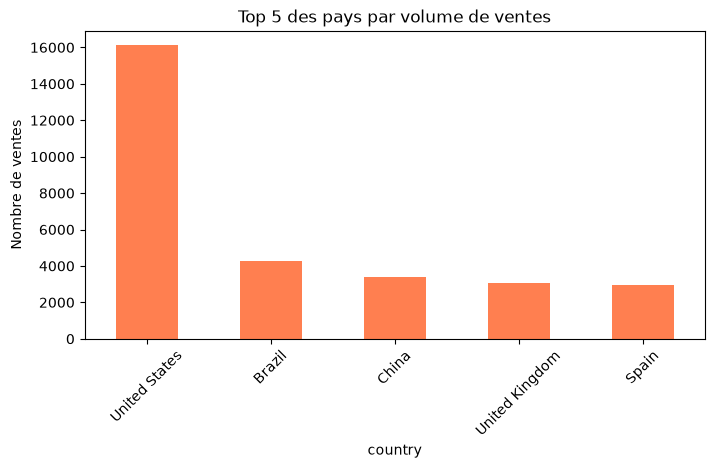

In [25]:
# Question Business 1 : Quelle est la répartition des ventes par pays (le Top 5) ?
top_countries = df['country'].value_counts().head(5)
print(top_countries)

top_countries.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Top 5 des pays par volume de ventes')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45)
plt.show()

tranche_age
36-50    37.2
26-35    34.0
18-25    20.2
50+       8.5
Name: proportion, dtype: float64


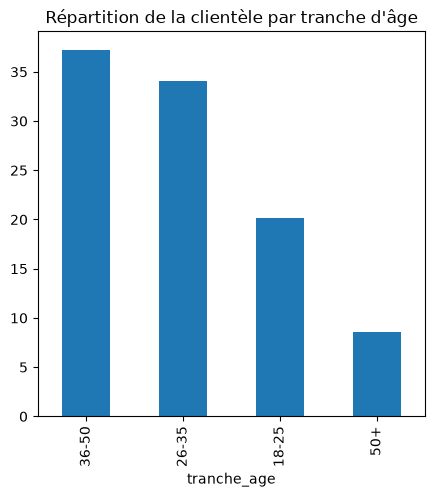

In [30]:
# Question Business 2 : La plateforme attire-t-elle plus une clientèle jeune (18-35 ans) ou âgée (36+) ?
repartition_age = df['tranche_age'].value_counts(normalize=True) * 100
print(repartition_age.round(1))

repartition_age.plot(kind='bar', figsize=(5, 5))
plt.title('Répartition de la clientèle par tranche d\'âge')
plt.ylabel('')
plt.show()
# -> L'audience est relativement équilibrée, avec une prédominance légère pour les jeunes / jeunes actifs.

department
Men      65.964377
Women    64.177194
Name: sale_price, dtype: float64


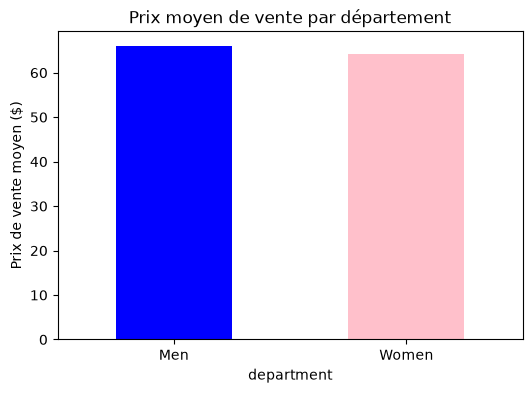

In [27]:
# Question Business 3 : Y a-t-il une différence de prix d'achat moyen entre les produits 'Women' et 'Men' ?
# Hypothèse : la colonne est 'department'
if 'department' in df.columns:
    mean_price_dept = df.groupby('department')['sale_price'].mean()
    print(mean_price_dept)
    
    mean_price_dept.plot(kind='bar', color=['blue', 'pink'], figsize=(6, 4))
    plt.title('Prix moyen de vente par département')
    plt.ylabel('Prix de vente moyen ($)')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("La colonne 'department' n'est pas présente dans ce dataset.")

---
## 🎤 PARTIE 5 : Préparation de la Soutenance (Synthèse Manager)

Rédigez ci-dessous la trame de votre soutenance. Résumez vos **3 découvertes les plus importantes** pour le comité de direction de TheLook. Ne décrivez pas votre code, décrivez la réalité du business (marges, problèmes de données récurrents chez les clients, profil type d'acheteur, etc.).